In [1]:
import pandas as pd

file_path = r"C:\Users\Shivani Singh\Downloads\mushroom_edibility.csv"

df = pd.read_csv(file_path)

print(df.head())
print(df.shape)

  SampleID CapShape CapColor    Odor GillSpacing GillColor StalkShape  \
0    S0001     flat     gray    foul     crowded     brown   tapering   
1    S0002   convex    brown  almond       close     white   tapering   
2    S0003   convex     gray    none     distant     black  enlarging   
3    S0004     flat   yellow    none       close     white  enlarging   
4    S0005  knobbed     gray   fishy       close      pink  enlarging   

  RingNumber  Habitat Population      Class  
0        one    woods  scattered  poisonous  
1       none  grasses    several     edible  
2        two   leaves  scattered  poisonous  
3        one    woods   abundant  poisonous  
4        one    urban    several  poisonous  
(600, 11)


In [2]:
print(df.columns)
print(df.info())

Index(['SampleID', 'CapShape', 'CapColor', 'Odor', 'GillSpacing', 'GillColor',
       'StalkShape', 'RingNumber', 'Habitat', 'Population', 'Class'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   SampleID     600 non-null    object
 1   CapShape     600 non-null    object
 2   CapColor     600 non-null    object
 3   Odor         600 non-null    object
 4   GillSpacing  600 non-null    object
 5   GillColor    600 non-null    object
 6   StalkShape   600 non-null    object
 7   RingNumber   600 non-null    object
 8   Habitat      600 non-null    object
 9   Population   600 non-null    object
 10  Class        600 non-null    object
dtypes: object(11)
memory usage: 51.7+ KB
None


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values in each column:
SampleID       0
CapShape       0
CapColor       0
Odor           0
GillSpacing    0
GillColor      0
StalkShape     0
RingNumber     0
Habitat        0
Population     0
Class          0
dtype: int64

Total missing values:
0


In [4]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [5]:
print(df.head())

  SampleID CapShape CapColor    Odor GillSpacing GillColor StalkShape  \
0    S0001     flat     gray    foul     crowded     brown   tapering   
1    S0002   convex    brown  almond       close     white   tapering   
2    S0003   convex     gray    none     distant     black  enlarging   
3    S0004     flat   yellow    none       close     white  enlarging   
4    S0005  knobbed     gray   fishy       close      pink  enlarging   

  RingNumber  Habitat Population      Class  
0        one    woods  scattered  poisonous  
1       none  grasses    several     edible  
2        two   leaves  scattered  poisonous  
3        one    woods   abundant  poisonous  
4        one    urban    several  poisonous  


In [6]:
import numpy as np
from math import log2

def calculate_entropy(y):
    counts = y.value_counts()
    total = len(y)
    
    entropy = 0
    
    for count in counts:
        probability = count / total
        entropy -= probability * log2(probability)
    
    return entropy

In [7]:
target_entropy = calculate_entropy(df['Class'])

print("Entropy of Class:", target_entropy)

Entropy of Class: 0.9822217784253526


In [8]:
def information_gain(df, feature, target):
    parent_entropy = calculate_entropy(df[target])
    
    weighted_entropy = 0
    
    for value in df[feature].unique():
        subset = df[df[feature] == value]
        
        weight = len(subset) / len(df)
        subset_entropy = calculate_entropy(subset[target])
        
        weighted_entropy += weight * subset_entropy
    
    return parent_entropy - weighted_entropy

In [9]:
features = [
    'CapShape',
    'CapColor',
    'Odor',
    'GillSpacing',
    'GillColor',
    'StalkShape',
    'RingNumber',
    'Habitat',
    'Population'
]

ig_results = []

for feature in features:
    ig = information_gain(df, feature, 'Class')
    ig_results.append([feature, ig])

ig_df = pd.DataFrame(
    ig_results,
    columns=['Feature', 'Information Gain']
)

ig_df = ig_df.sort_values(
    by='Information Gain',
    ascending=False
)

print(ig_df)

       Feature  Information Gain
2         Odor          0.342720
7      Habitat          0.014779
3  GillSpacing          0.014612
1     CapColor          0.009505
8   Population          0.006421
4    GillColor          0.005488
5   StalkShape          0.004876
6   RingNumber          0.003420
0     CapShape          0.002740


In [11]:
X = df.drop(columns=['Class', 'SampleID'])
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (600, 9)
y shape: (600,)


In [12]:
X_encoded = pd.get_dummies(X, drop_first=False)

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)

print(X_encoded.head())

Original shape: (600, 9)
Encoded shape: (600, 37)
   CapShape_bell  CapShape_convex  CapShape_flat  CapShape_knobbed  \
0          False            False           True             False   
1          False             True          False             False   
2          False             True          False             False   
3          False            False           True             False   
4          False            False          False              True   

   CapColor_brown  CapColor_gray  CapColor_red  CapColor_white  \
0           False           True         False           False   
1            True          False         False           False   
2           False           True         False           False   
3           False          False         False           False   
4           False           True         False           False   

   CapColor_yellow  Odor_almond  ...  RingNumber_two  Habitat_grasses  \
0            False        False  ...           False       

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")

for i, class_name in enumerate(label_encoder.classes_):
    print(class_name, "=", i)

Class mapping:
edible = 0
poisonous = 1


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (480, 37)
Testing data: (120, 37)


In [15]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [16]:
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Predictions:")
print(y_pred_nb)

Naive Bayes Predictions:
[1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 1 1 1 0 1 0 0 0 1
 1 0 0 0 1 1 0 1 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0
 0 0 1 1 0 1 0 1 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 1 1 1 1 0 1 0 0 1
 1 1 0 1 1 1 0 1 0]


In [17]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy * 100, "%")

Naive Bayes Accuracy: 75.83333333333333 %


In [18]:
from sklearn.metrics import confusion_matrix, classification_report

cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Confusion Matrix:")
print(cm_nb)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=label_encoder.classes_
))

Confusion Matrix:
[[44  7]
 [22 47]]

Classification Report:
              precision    recall  f1-score   support

      edible       0.67      0.86      0.75        51
   poisonous       0.87      0.68      0.76        69

    accuracy                           0.76       120
   macro avg       0.77      0.77      0.76       120
weighted avg       0.78      0.76      0.76       120



In [19]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [20]:
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Predictions:")
print(y_pred_dt)

Decision Tree Predictions:
[1 1 0 0 1 1 1 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 1 1 0 1 1 0 1 0 0 0 0 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 0 0 0 1 1 1 0 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 0 1 1]


In [21]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy * 100, "%")

Decision Tree Accuracy: 67.5 %


In [22]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=label_encoder.classes_
))

Confusion Matrix:
[[23 28]
 [11 58]]

Classification Report:
              precision    recall  f1-score   support

      edible       0.68      0.45      0.54        51
   poisonous       0.67      0.84      0.75        69

    accuracy                           0.68       120
   macro avg       0.68      0.65      0.64       120
weighted avg       0.68      0.68      0.66       120



In [23]:
comparison = pd.DataFrame({
    'Model': ['Naive Bayes', 'Decision Tree'],
    'Accuracy': [
        nb_accuracy * 100,
        dt_accuracy * 100
    ]
})

print(comparison)

           Model   Accuracy
0    Naive Bayes  75.833333
1  Decision Tree  67.500000


In [24]:
if nb_accuracy > dt_accuracy:
    print("Best Model: Naive Bayes")
else:
    print("Best Model: Decision Tree")

Best Model: Naive Bayes


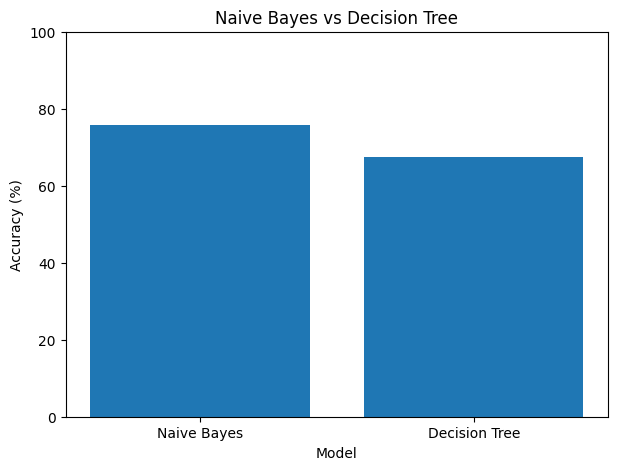

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Naive Bayes vs Decision Tree")

plt.ylim(0, 100)
plt.show()

In [26]:
new_mushroom = pd.DataFrame({
    'CapShape': ['convex'],
    'CapColor': ['brown'],
    'Odor': ['none'],
    'GillSpacing': ['close'],
    'GillColor': ['white'],
    'StalkShape': ['tapering'],
    'RingNumber': ['one'],
    'Habitat': ['woods'],
    'Population': ['several']
})

print(new_mushroom)

  CapShape CapColor  Odor GillSpacing GillColor StalkShape RingNumber Habitat  \
0   convex    brown  none       close     white   tapering        one   woods   

  Population  
0    several  


In [27]:
new_mushroom_encoded = pd.get_dummies(new_mushroom)

new_mushroom_encoded = new_mushroom_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

print(new_mushroom_encoded)

   CapShape_bell  CapShape_convex  CapShape_flat  CapShape_knobbed  \
0              0             True              0                 0   

   CapColor_brown  CapColor_gray  CapColor_red  CapColor_white  \
0            True              0             0               0   

   CapColor_yellow  Odor_almond  ...  RingNumber_two  Habitat_grasses  \
0                0            0  ...               0                0   

   Habitat_leaves  Habitat_paths  Habitat_urban  Habitat_woods  \
0               0              0              0           True   

   Population_abundant  Population_scattered  Population_several  \
0                    0                     0                True   

   Population_solitary  
0                    0  

[1 rows x 37 columns]


In [28]:
nb_prediction = nb_model.predict(new_mushroom_encoded)

print(
    "Naive Bayes Prediction:",
    label_encoder.inverse_transform(nb_prediction)[0]
)

Naive Bayes Prediction: edible


In [29]:
dt_prediction = dt_model.predict(new_mushroom_encoded)

print(
    "Decision Tree Prediction:",
    label_encoder.inverse_transform(dt_prediction)[0]
)

Decision Tree Prediction: poisonous


In [30]:
print("Naive Bayes Probability:")
for class_name, probability in zip(
    label_encoder.classes_,
    nb_model.predict_proba(new_mushroom_encoded)[0]
):
    print(class_name, ":", round(probability * 100, 2), "%")


print("\nDecision Tree Probability:")
for class_name, probability in zip(
    label_encoder.classes_,
    dt_model.predict_proba(new_mushroom_encoded)[0]
):
    print(class_name, ":", round(probability * 100, 2), "%")

Naive Bayes Probability:
edible : 95.93 %
poisonous : 4.07 %

Decision Tree Probability:
edible : 43.33 %
poisonous : 56.67 %
